# Examen Machine Learning I
## Universidad Mayor

**Alumna:** Paulina Godoy

## Metadatos del dataset

- **Nombre del dataset:** California Housing Dataset
- **Fuente:** StatLib
- **URL:** https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html
- **Número de filas:** 20640
- **Número de columnas:** 9
- **Variable Objetivo:** MedHouseVal
- **Timpo de tarea**: Regresión

### Importación de librerías y configuración

In [55]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor

In [30]:
# Configuración de estilo para gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 11, 'axes.titlesize': 12, 'figure.titlesize': 14})

In [31]:
# Creamos la carpeta 'figures/' si no existe
os.makedirs('figures', exist_ok=True)
print("Carpeta 'figures/' verificada/creada exitosamente.")

Carpeta 'figures/' verificada/creada exitosamente.


### Carga de datos y revisión inicial

In [32]:
# Cargamos el dataset de California Housing
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [33]:
# Revisión de dimensiones, tipos de datos y estadísticas descriptivas
print("------ Shape ------")
print(df.shape)
print("------ Tipos de datos por columna (dtypes) ------")
print(df.dtypes)
print("------ Info ------")
df.info()
print("------ Estadísticas descriptivas iniciales ------")
df.describe()

------ Shape ------
(20640, 9)
------ Tipos de datos por columna (dtypes) ------
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object
------ Info ------
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
------ Estadísticas descriptivas iniciales ------


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [34]:
print("----- 5 primeras filas -----")
df.head()

----- 5 primeras filas -----


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Análisis y tratamiento de valores nulos

Porcentaje de valores nulos por columna:
MedInc         0.0
HouseAge       0.0
AveRooms       0.0
AveBedrms      0.0
Population     0.0
AveOccup       0.0
Latitude       0.0
Longitude      0.0
MedHouseVal    0.0
dtype: float64


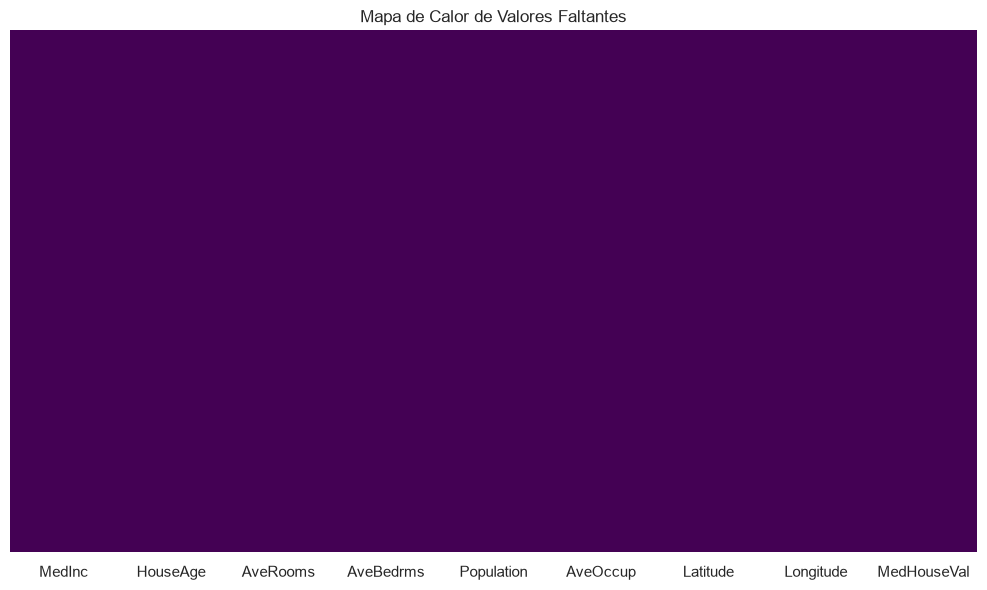

In [35]:
# Porcentaje de nulos por columna
null_percentages = df.isnull().mean() * 100
print("Porcentaje de valores nulos por columna:")
print(null_percentages.round(4))

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Faltantes')
plt.tight_layout()
plt.savefig('figures/01_missing_values_heatmap.png', dpi=150)
plt.show()

**Justificación de tratamiento de valores nulos:** Ya que el dataset no contiene valores nulos en ninguna de las columnas, no se requiere imputación ni eliminación de columnas. Sin embargo, para seguir buenas prácticas de robustez del pipeline, se incluirá un SimpleImputer(strategy='median') dentro del ColumnTransformer. De esta forma, el flujo de procesamiento será reproducible con nuevaos datos que sí pudieran contener nulos.

### Detección y tratamiento de outliers

**Nota:** En la primera iteración de esta sección se detectó que la variables clave tienen escalas muy distintas entre si, por lo que se tomó la decisión de graficar los boxplots en paneles individuales, ya que graficarlos juntos hace ilegibles a las variables de menor magnitud.

Adicionalmente, es relevante notar que el filtrado por IQR se aplica de forma simultánea. Es decir, los límites (Q1, Q3) de cada variable se calculan siempre sobre el dataset original completo, y luego se combinan todas las condiciones en una única máscara booleana. Así se evita que el orden de las cariables en key_variables afecte el resultado final.

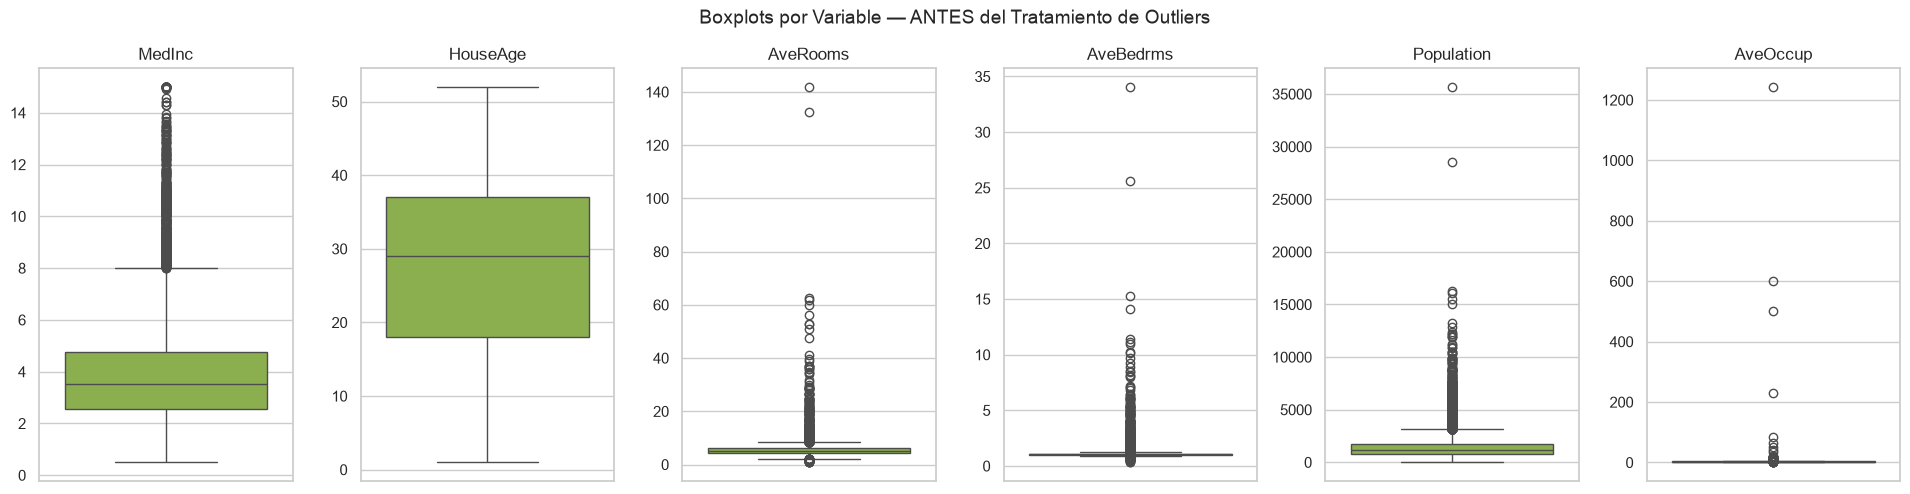

In [36]:
key_variables = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']

def plot_boxplots_por_variable(data, variables, filename, titulo):
    fig, axes = plt.subplots(1, len(variables), figsize=(3.2*len(variables), 5))
    for ax, var in zip(axes, variables):
        sns.boxplot(y=data[var], ax=ax, color='#8FBF3F')
        ax.set_title(var)
        ax.set_ylabel('')
    fig.suptitle(titulo)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

plot_boxplots_por_variable(df, key_variables, 'figures/02_boxplots_antes_outliers.png',
                            'Boxplots por Variable — ANTES del Tratamiento de Outliers')


In [37]:
# Diagnóstico de outliers por variable (sobre el dataset ORIGINAL, sin cascada)
print(f"Filas antes de remover outliers: {len(df)}\n")

limites_iqr = {}
mask = pd.Series(True, index=df.index)

for col in key_variables:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    limites_iqr[col] = (lower_limit, upper_limit)

    n_out = ((df[col] < lower_limit) | (df[col] > upper_limit)).sum()
    print(f"{col:12s}: {n_out:5d} outliers ({n_out/len(df)*100:5.2f}%) | límites=[{lower_limit:9.2f}, {upper_limit:9.2f}]")

    mask &= df[col].between(lower_limit, upper_limit)

df_clean = df[mask].copy()

print(f"\nFilas después de remover outliers por método IQR: {len(df_clean)}")
print(f"Observaciones eliminadas: {len(df) - len(df_clean)} ({((len(df) - len(df_clean))/len(df)*100):.2f}%)")


Filas antes de remover outliers: 20640

MedInc      :   681 outliers ( 3.30%) | límites=[    -0.71,      8.01]
HouseAge    :     0 outliers ( 0.00%) | límites=[   -10.50,     65.50]
AveRooms    :   511 outliers ( 2.48%) | límites=[     2.02,      8.47]
AveBedrms   :  1424 outliers ( 6.90%) | límites=[     0.87,      1.24]
Population  :  1196 outliers ( 5.79%) | límites=[  -620.00,   3132.00]
AveOccup    :   711 outliers ( 3.44%) | límites=[     1.15,      4.56]

Filas después de remover outliers por método IQR: 16842
Observaciones eliminadas: 3798 (18.40%)


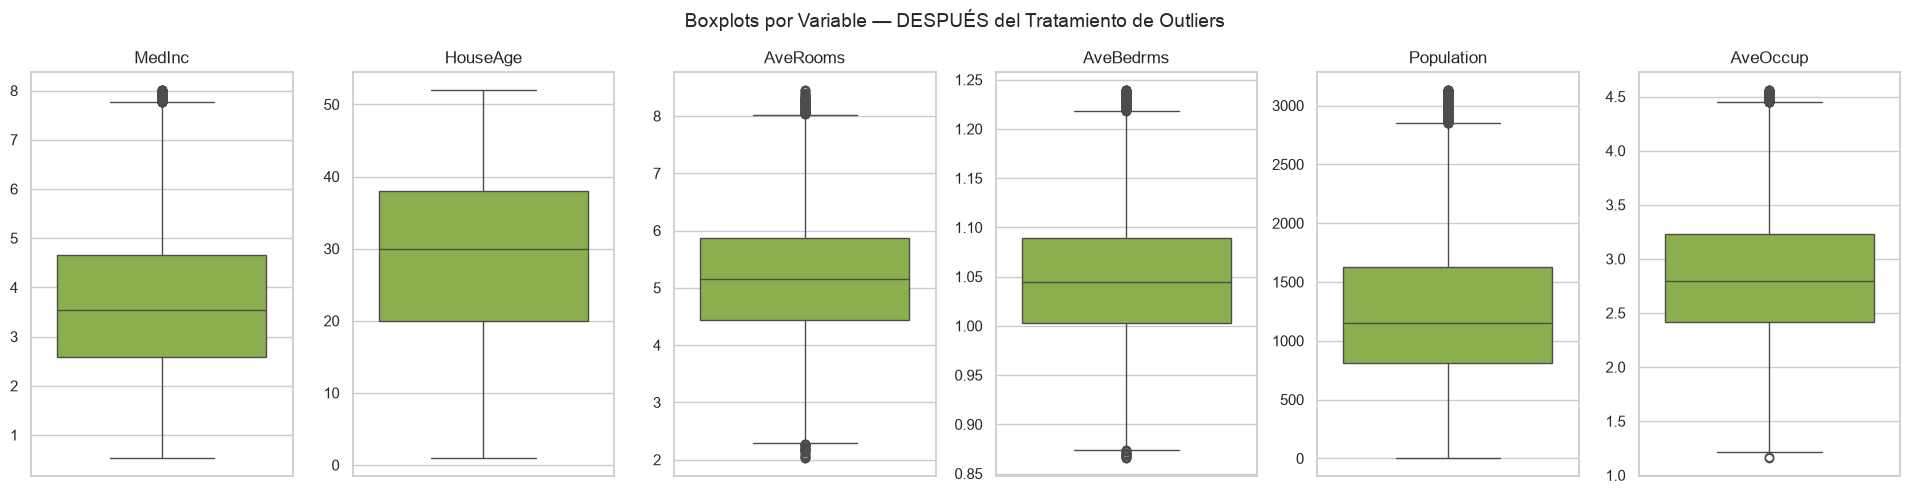

In [38]:
plot_boxplots_por_variable(df_clean, key_variables, 'figures/03_boxplots_despues_outliers.png',
                            'Boxplots por Variable — DESPUÉS del Tratamiento de Outliers')


**Conclusiones EDA:** 

Podemos observar que la única variable sin outliers es HouseAge, por lo que su rango antes y después del filtro aplicado permanece sin cambios. Por otro lado, las variables AveBedrms, Population y AveOccup presentaron la mayor proporción de outliers. 

También llama la atención que la suma de outliers indiviuales (4523) es nayor que el total combinado (3798). Esto indica que muchas filas son outliers en más de una variable, y se produce solapamiento.

Si revisamos los boxplots después del filtro, siguen apareciiendo puntos fuera de los bigotes. Esto es esperable, ya que el boxplot recalcula los cuartiles sobre los datos ya filtrados. Por esta razón, siempre existirá un pequeño porcentaje en los extremos de la nueva distribución.


### Distribución de la variable objetivo

Asimetría (Skewness) de la variable objetivo: 0.9265


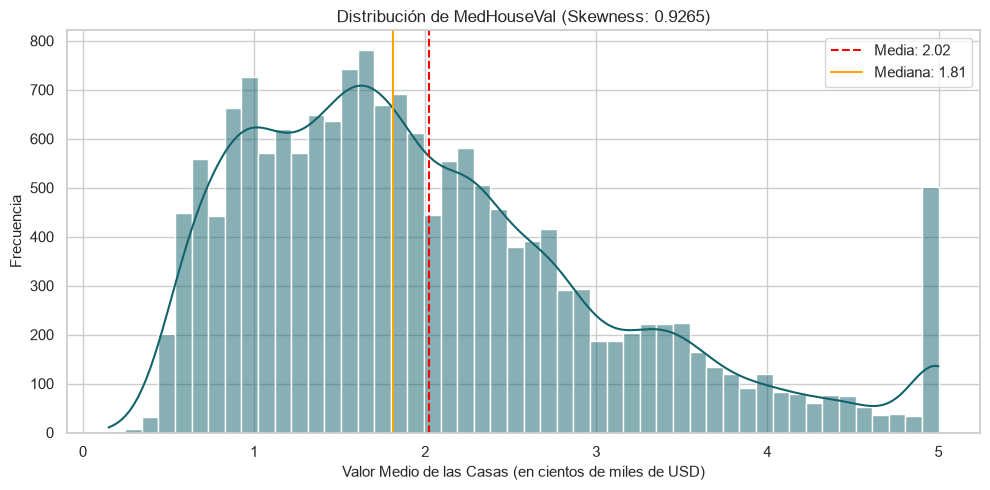

In [51]:
skew_val = df_clean['MedHouseVal'].skew()
print(f"Asimetría (Skewness) de la variable objetivo: {skew_val:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_clean['MedHouseVal'], kde=True, color='#12636B', bins=50, ax=ax)
ax.axvline(df_clean['MedHouseVal'].mean(), color='red', linestyle='--', label=f"Media: {df_clean['MedHouseVal'].mean():.2f}")
ax.axvline(df_clean['MedHouseVal'].median(), color='orange', linestyle='-', label=f"Mediana: {df_clean['MedHouseVal'].median():.2f}")
ax.set_title(f'Distribución de MedHouseVal (Skewness: {skew_val:.4f})')
ax.set_xlabel('Valor Medio de las Casas (en cientos de miles de USD)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig('figures/04_target_distribution.png', dpi=150)
plt.show()

In [52]:
# Evaluación condicional de transformación logarítmica (exigido por Punto 7)
usar_log_target = skew_val > 1.0
print(f"¿Skewness > 1.0? {usar_log_target}")

if usar_log_target:
    df_clean['target_log'] = np.log1p(df_clean['MedHouseVal'])  # log1p para manejar posibles ceros
    skew_log = df_clean['target_log'].skew()
    print(f"Skewness original: {skew_val:.4f} -> Skewness tras log1p: {skew_log:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(df_clean['MedHouseVal'], kde=True, ax=axes[0], color='#12636B', bins=50)
    axes[0].set_title(f'Target original (skew={skew_val:.3f})')
    sns.histplot(df_clean['target_log'], kde=True, ax=axes[1], color='darkorange', bins=50)
    axes[1].set_title(f'Target transformado log1p (skew={skew_log:.3f})')
    plt.tight_layout()
    plt.savefig('figures/04b_target_log_transform.png', dpi=150)
    plt.show()
else:
    print("No se aplica transformación logarítmica: la asimetría no supera el umbral de 1.0 definido en la ficha.")


¿Skewness > 1.0? False
No se aplica transformación logarítmica: la asimetría no supera el umbral de 1.0 definido en la ficha.


**Distribución de la variable objetivo:** Se observa un skewness de 0.9265 de la variable objetivo MedHouseVal, lo que inica una asimetría positiva moderada. Debido a que la ficha del examen establace que sólo se debe aplicar una transformación logarítmica cuando el skewness supera el valor 1.0, no corresponde aplicar dicha transformación y el modelo se realiza sobre su escala original. 

En el gráfico podemos observar una acumulación anómala de observaciones en el valor 5.0, límite superior de la variable. Esto se debe a una censura de datos propia del dataset (los valores de vivienda iguales o superiores a 500000 USD fueron truncados a ese techo durante la recolección original).

### Visualizaciones exploratorias

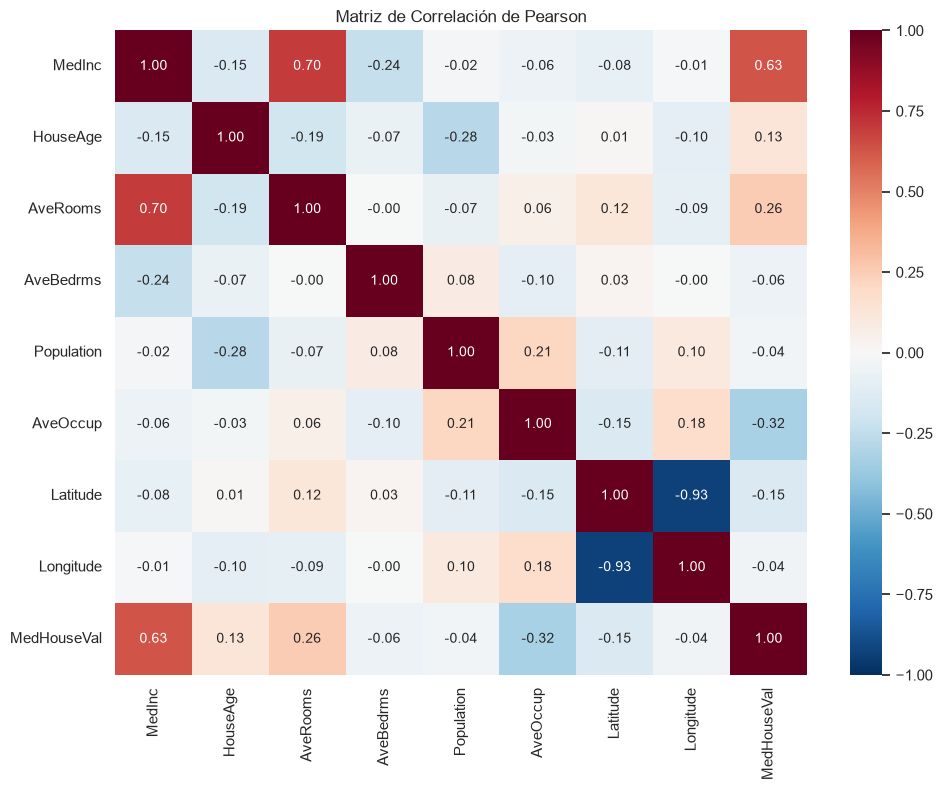

In [41]:
# Heatmap de correlación de Pearson
plt.figure(figsize=(10, 8))
correlation_matrix = df_clean.drop(columns=[c for c in ['target_log'] if c in df_clean.columns]).corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Pearson')
plt.tight_layout()
plt.savefig('figures/05_correlation_heatmap.png', dpi=150)
plt.show()

Las dos variables más correlacionadas con el target son:
  - MedInc: r = 0.6295
  - AveOccup: r = -0.3228


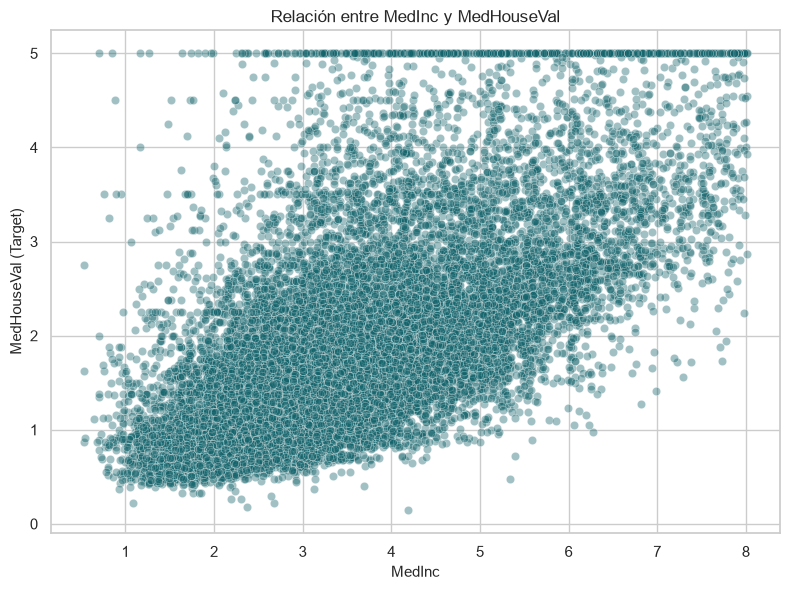

In [43]:
# Scatter plot entre las 2 variables más correlacionadas con el target
corrs_with_target = correlation_matrix['MedHouseVal'].abs().sort_values(ascending=False)
top_predictors = corrs_with_target.index[1:3]  # excluye target mismo
print("Las dos variables más correlacionadas con el target son:")
for pred in top_predictors:
    print(f"  - {pred}: r = {correlation_matrix.loc['MedHouseVal', pred]:.4f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x=top_predictors[0], y='MedHouseVal', alpha=0.4, color='#12636B')
plt.title(f'Relación entre {top_predictors[0]} y MedHouseVal')
plt.xlabel(top_predictors[0])
plt.ylabel('MedHouseVal (Target)')
plt.tight_layout()
plt.savefig('figures/06_scatter_top_correlated.png', dpi=150)
plt.show()

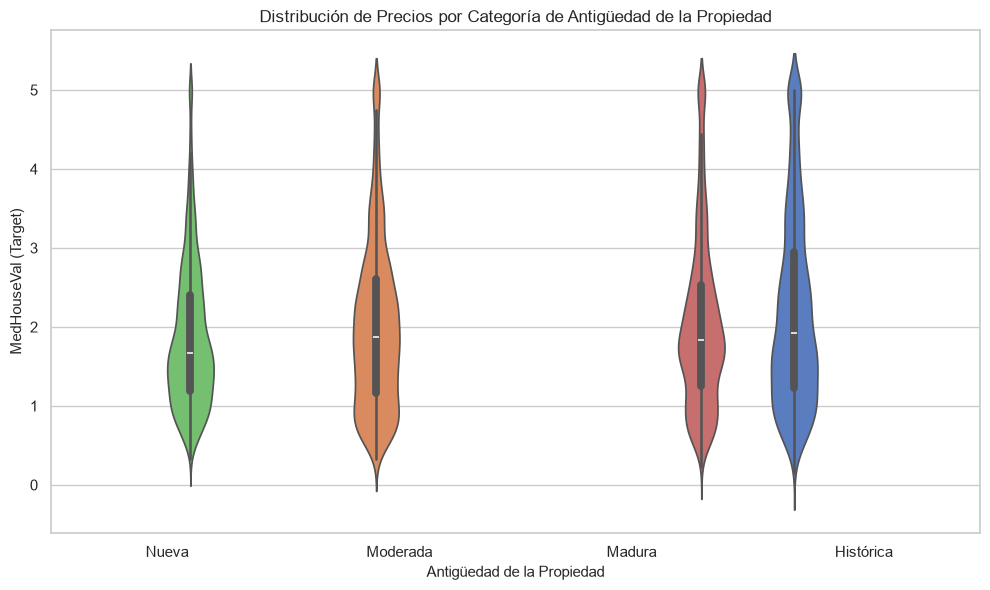

In [47]:
# Violin plot adicional: distribución del target por categoría de antigüedad de la vivienda
df_clean['HouseAge_Bin'] = pd.qcut(df_clean['HouseAge'], q=4, labels=['Nueva', 'Moderada', 'Madura', 'Histórica'])

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_clean, x='HouseAge_Bin', y='MedHouseVal', hue='HouseAge_Bin', palette='muted', legend=False)
plt.title('Distribución de Precios por Categoría de Antigüedad de la Propiedad')
plt.xlabel('Antigüedad de la Propiedad')
plt.ylabel('MedHouseVal (Target)')
plt.tight_layout()
plt.savefig('figures/07_violin_plot.png', dpi=150)
plt.show()

### Multicoliealidad entre predictores

In [49]:
# Top 5 variables más correlacionadas con el target + multicolinealidad entre predictores
print("Top 5 variables más correlacionadas con el target (valor absoluto):")
top_5_corr = corrs_with_target.iloc[1:6]
print(top_5_corr.round(4))

print("\nEvaluando multicolinealidad entre predictores (|r| > 0.85):")
predictor_corr = correlation_matrix.drop(index='MedHouseVal', columns='MedHouseVal')
high_corr_pairs = []
for i in range(len(predictor_corr.columns)):
    for j in range(i):
        val = predictor_corr.iloc[i, j]
        if abs(val) > 0.85:
            high_corr_pairs.append((predictor_corr.columns[i], predictor_corr.columns[j], val))

if not high_corr_pairs:
    print("No se detectó multicolinealidad crítica (|r| > 0.85) entre las variables predictoras.")
else:
    print("Variables predictoras con multicolinealidad (|r| > 0.85):")
    for a, b, v in high_corr_pairs:
        print(f"  - {a} y {b}: r = {v:.4f}")

Top 5 variables más correlacionadas con el target (valor absoluto):
MedInc      0.6295
AveOccup    0.3228
AveRooms    0.2555
Latitude    0.1471
HouseAge    0.1267
Name: MedHouseVal, dtype: float64

Evaluando multicolinealidad entre predictores (|r| > 0.85):
Variables predictoras con multicolinealidad (|r| > 0.85):
  - Longitude y Latitude: r = -0.9336


**Variables más correlacionadas con MedHouseVal:** La variable MedInc (ingreso medio del distrito) es el predictor inividual más fuerte del valor de la vivienda. A esta variable la siguen AveOccup, AveRooms, Latitude y HouseAge, para conformar las 5 variables más correlacionadas con el target.  

**Multicolinealidad:** Se identificó un único par que supera el umbral crítico (|r|>0.85), Longitude y Latitude, con r=-0.9336. 

### Divisón de datos en train/test

In [53]:
X = df_clean.drop(columns=[c for c in ['MedHouseVal', 'MedHouseVal_log'] if c in df_clean.columns])
y = df_clean['MedHouseVal_log'] if usar_log_target else df_clean['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test:  {X_test.shape}")

Dimensiones de X_train: (13473, 9)
Dimensiones de X_test:  (3369, 9)


### ColumnTransformer (pipeline de preprocesamiento)

In [56]:
numeric_features = X.columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features)
])

# Ajustar SOLO con X_train para evitar data leakage
X_train_prep = preprocessor.fit_transform(X_train)
# Aplicar únicamente transform sobre X_test
X_test_prep = preprocessor.transform(X_test)

print("Pipeline ColumnTransformer (Imputer + StandardScaler) ejecutado sin data leakage.")
print(f"X_train_prep shape: {X_train_prep.shape} | X_test_prep shape: {X_test_prep.shape}")


ValueError: Cannot use median strategy with non-numeric data:
could not convert string to float: 'Histórica'